# Project Title: Transfer Learning with ResNet18 for CR7 Face Classification

## Project Overview

In this project, I build an image classifier to determine whether a face image is Cristiano Ronaldo (CR7) or not CR7. Instead of training a convolutional neural network from the start, I use transfer learning. This approach allows me to use a model that has already learned useful features from a large dataset of images.

The model I use is ResNet18, a pre-trained convolutional neural network from the PyTorch torchvision library. Since ResNet18 was originally trained on ImageNet, it can recognize many important features in images, like edges, textures, facial shapes, and patterns. I modify the final classification layer so that the model can solve this binary classification problem.

The dataset is organized into two classes:

- **CR7**
- **Not CR7**

The notebook is organized as a final project report. It covers the following sections: preparing the dataset, preprocessing the data, choosing a model, setting up transfer learning, training the model, adjusting hyperparameters, evaluating results, testing predictions, discussing findings, concluding the project, and listing references.

## Dataset Description

The dataset in this project contains facial images for a binary classification task. One class contains images of **Cristiano Ronaldo (CR7)**, while the other class contains images of people who are **not Cristiano Ronaldo**.

This project uses the Hugging Face dataset jtatman/one_twenty_five_faces, an image dataset with about 20.1k rows and 125 class labels. I used this dataset to build a binary face-classification task by selecting Cristiano Ronaldo CR7 as the target class and grouping all remaining identities into the not CR7.

To make the project compatible with PyTorch’s ImageFolder format, the data is organized into the following directory structure:

```text
data/
    train/
        target/
        other/
    test/
        target/
        other/

In [152]:
import os
import random
import shutil
import copy
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from datasets import load_dataset

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [154]:
d = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", d)

Device: cuda


In [155]:
!pip install -U datasets huggingface_hub

In [156]:
ds = load_dataset("jtatman/one_twenty_five_faces")
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 20096
    })
})

In [157]:
lb = ds["train"].features["label"].names
print("classes:", len(lb))

for i, n in enumerate(lb):
    print(i, n)

classes: 125
0 Adriana_Lima
1 Akshay_Kumar
2 Alex_Lawther
3 Alexandra_Daddario
4 Alia_Bhatt
5 Allen_Page
6 Alvaro_Morte
7 Alycia_Debnam-Carey
8 Amanda_Crew
9 Amber_Heard
10 Amitabh_Bachchan
11 Andy_Samberg
12 Anne_Hathaway
13 Anthony_Mackie
14 Anushka_Sharma
15 Avril_Lavigne
16 Barack_Obama
17 Barbara_Palvin
18 Ben_Affleck
19 Bill_Gates
20 Billie_Eilish
21 Bobby_Morley
22 Brad_Pitt
23 Brenton_Thwaites
24 Brian_J_Smith
25 Brie_Larson
26 Camila_Cabello
27 Camila_Mendes
28 Carlize_Theron
29 Chris_Evans
30 Chris_Hemsworth
31 Chris_Pratt
32 Christian_Bale
33 Christiano_Ronaldo
34 Claire_Holt
35 Courtney_Cox
36 Danielle_Panabaker
37 Dominic_Purcell
38 Dwayne_Johnson
39 Eliza_Taylor
40 Elizabeth_Lail
41 Elizabeth_Olsen
42 Ellen_Degeneres
43 Elon_Musk
44 Emilia_Clarke
45 Emma_Stone
46 Emma_Watson
47 Gal_Gadot
48 Grant_Gustin
49 Gwyneth_Paltrow
50 Harmik
51 Henry_Cavill
52 Hrithik_Roshan
53 Hugh_Jackman
54 Inbar_Lavi
55 Irina_Shayk
56 Jake_McDorman
57 Jason_Momoa
58 Jeff_Bezos
59 Jennifer_Lawre

In [158]:
t = 33
print("using:", lb[t])

using: Christiano_Ronaldo


In [159]:
dt = ds["train"]

a = [i for i, x in enumerate(dt) if x["label"] == t]
b = [i for i, x in enumerate(dt) if x["label"] != t]

print("target imgs:", len(a))
print("other imgs:", len(b))
print("target name:", lb[t])

target imgs: 98
other imgs: 19998
target name: Christiano_Ronaldo


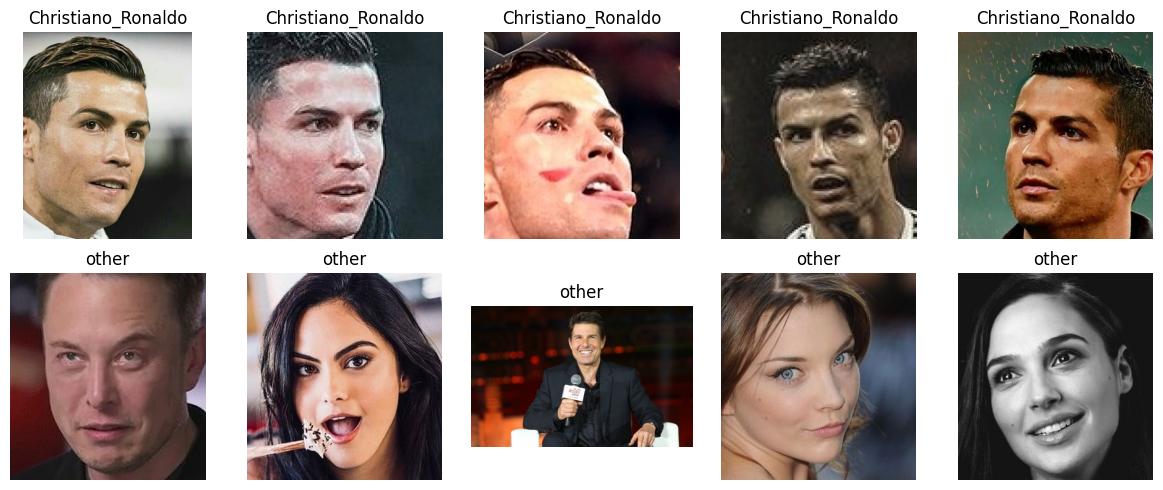

In [202]:
fig, ax = plt.subplots(2, 5, figsize=(12, 5))

for j in range(5):
    ax[0, j].imshow(dt[a[j]]["image"])
    ax[0, j].set_title(lb[t])
    ax[0, j].axis("off")

for j in range(5):
    ax[1, j].imshow(dt[b[j]]["image"])
    ax[1, j].set_title("other")
    ax[1, j].axis("off")

plt.tight_layout()
plt.show()

In [203]:
p = "data"

for x in [
    f"{p}/train/target",
    f"{p}/train/other",
    f"{p}/test/target",
    f"{p}/test/other",
]:
    os.makedirs(x, exist_ok=True)

In [204]:
random.seed(42)

random.shuffle(a)
random.shuffle(b)

m = min(len(a), 150)
a = a[:m]
b = b[:m]

sa = int(0.8 * len(a))
sb = int(0.8 * len(b))

a_tr, a_ts = a[:sa], a[sa:]
b_tr, b_ts = b[:sb], b[sb:]

print(len(a_tr), len(a_ts), len(b_tr), len(b_ts))

78 20 78 20


In [205]:
def sv(ix, od, pf):
    for k, i in enumerate(ix):
        img = dt[i]["image"]
        img.save(f"{od}/{pf}_{k}.jpg")

In [206]:
sv(a_tr, f"{p}/train/target", "t")
sv(a_ts, f"{p}/test/target", "t")
sv(b_tr, f"{p}/train/other", "o")
sv(b_ts, f"{p}/test/other", "o")

In [207]:
for x in [
    f"{p}/train/target",
    f"{p}/train/other",
    f"{p}/test/target",
    f"{p}/test/other",
]:
    print(x, len(os.listdir(x)))

data/train/target 120
data/train/other 120
data/test/target 30
data/test/other 30



## Preprocessing and Data Augmentation

When working with images in computer models, it’s important that all images are the same size. In this project, I adjust all images to be 224 by 224 pixels, which is the size required by a specific model called ResNet18.

To help the model learn better and perform well on new images, I use a technique known as data augmentation. This means I make slight changes to my training images, such as flipping them sideways, rotating them a little, or adjusting their colors. These changes mimic the natural variations I see in images, which helps the model adapt better and reduces the risk of it becoming overly focused on specific details.

For the test set, however, I don’t apply these modifications. I keep the test images stable and unchanged because I want to evaluate how well the model performs on images that resemble real-world inputs. For the test set, I only resize the images and convert them into a format the model can understand.

In [208]:
tr = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor()
])

ts = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [209]:
tr_ds = datasets.ImageFolder(f"{p}/train", transform=tr)
ts_ds = datasets.ImageFolder(f"{p}/test", transform=ts)

tr_dl = DataLoader(tr_ds, batch_size=16, shuffle=True)
ts_dl = DataLoader(ts_ds, batch_size=16, shuffle=False)

print(tr_ds.classes)
print(len(tr_ds), len(ts_ds))

['other', 'target']
240 60


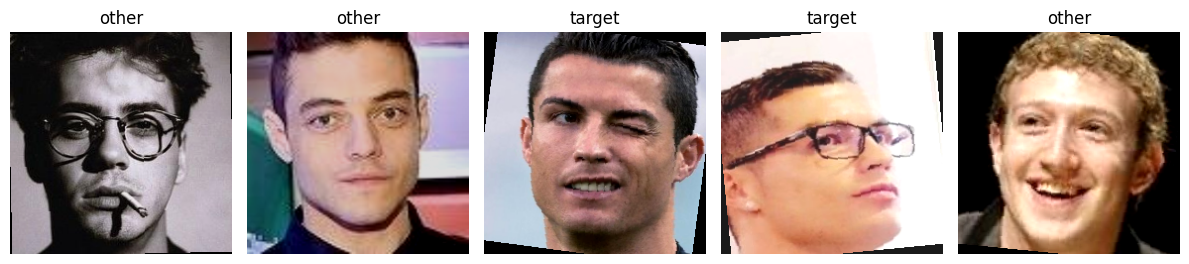

In [230]:
x, y = next(iter(tr_dl))

fig, ax = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    ax[i].imshow(x[i].permute(1, 2, 0))
    ax[i].set_title(tr_ds.classes[y[i].item()])
    ax[i].axis("off")
plt.tight_layout()
plt.show()

## Model Selection

The project uses ResNet18, a pre-trained neural network from the PyTorch torchvision package. ResNet18 helps deep neural networks train better by adding shortcut connections between layers.

This model is great for transfer learning since it has valuable visual knowledge from ImageNet. Instead of learning everything from the beginning, the model can use this prior knowledge and adapt it to the CR7 face-classification task.

Since the original ResNet18 outputs 1000 ImageNet classes, I replace its final fully connected layer with a new layer that outputs only 2 classes.:

- CR7
- Not CR7

In [231]:
m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for q in m.parameters():
    q.requires_grad = False

f = m.fc.in_features
m.fc = nn.Linear(f, 2)
m = m.to(d)

m

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Hyperparameter Adjustment

To improve the model, I changed a few settings during training.

I started with a batch size of 16. This size helps keep the updates stable while still fitting in memory. I chose a learning rate of 0.005, which works well for training only the final classification layer of a pre-trained network.

I trained the model for several epochs to give it enough time to learn from the new dataset. If the number of epochs is too low, the model might not learn the CR7 facial patterns properly. If it's too high, the model might just memorize the training images and not learn to recognize new ones.

I also used data augmentation to make the model more robust. These changes help the model perform better when it sees new face images that are not in the training set.

In [232]:
lf = nn.CrossEntropyLoss()
op = optim.Adam(m.fc.parameters(), lr=0.005)
ep = 100

In [234]:
def ev(md, dl):
    md.eval()
    ls = 0
    cr = 0
    nnn = 0
    yp = []
    yt = []

    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(d), y.to(d)
            z = md(x)
            l = lf(z, y)

            ls += l.item() * x.size(0)

            p = torch.argmax(z, dim=1)
            cr += (p == y).sum().item()
            nnn += y.size(0)

            yp.extend(p.cpu().numpy())
            yt.extend(y.cpu().numpy())

    return ls / nnn, cr / nnn, yp, yt

In [235]:
h = {"tr_l": [], "tr_a": [], "ts_l": [], "ts_a": []}

bw = copy.deepcopy(m.state_dict())
ba = 0.0

for e in range(ep):
    m.train()
    ls = 0
    cr = 0
    nnn = 0

    for x, y in tr_dl:
        x, y = x.to(d), y.to(d)

        op.zero_grad()
        z = m(x)
        l = lf(z, y)
        l.backward()
        op.step()

        ls += l.item() * x.size(0)
        p = torch.argmax(z, dim=1)
        cr += (p == y).sum().item()
        nnn += y.size(0)

    tr_l = ls / nnn
    tr_a = cr / nnn

    ts_l, ts_a, _, _ = ev(m, ts_dl)

    h["tr_l"].append(tr_l)
    h["tr_a"].append(tr_a)
    h["ts_l"].append(ts_l)
    h["ts_a"].append(ts_a)

    if ts_a > ba:
        ba = ts_a
        bw = copy.deepcopy(m.state_dict())

    print(f"ep {e+1}/{ep} | tr_l {tr_l:.4f} | tr_a {tr_a:.4f} | ts_l {ts_l:.4f} | ts_a {ts_a:.4f}")

m.load_state_dict(bw)
print("best test acc:", ba)

ep 1/100 | tr_l 0.8542 | tr_a 0.5333 | ts_l 0.8773 | ts_a 0.5167
ep 2/100 | tr_l 0.6162 | tr_a 0.6458 | ts_l 0.6197 | ts_a 0.6333
ep 3/100 | tr_l 0.5222 | tr_a 0.7542 | ts_l 0.5563 | ts_a 0.6667
ep 4/100 | tr_l 0.5440 | tr_a 0.7000 | ts_l 0.7485 | ts_a 0.6500
ep 5/100 | tr_l 0.6521 | tr_a 0.7125 | ts_l 0.7064 | ts_a 0.6333
ep 6/100 | tr_l 0.4732 | tr_a 0.7833 | ts_l 0.5338 | ts_a 0.7333
ep 7/100 | tr_l 0.4489 | tr_a 0.7875 | ts_l 0.6310 | ts_a 0.6667
ep 8/100 | tr_l 0.5087 | tr_a 0.7667 | ts_l 0.6427 | ts_a 0.6833
ep 9/100 | tr_l 0.4020 | tr_a 0.8083 | ts_l 0.5314 | ts_a 0.7667
ep 10/100 | tr_l 0.4132 | tr_a 0.8042 | ts_l 0.5249 | ts_a 0.7833
ep 11/100 | tr_l 0.4879 | tr_a 0.7542 | ts_l 0.7902 | ts_a 0.6667
ep 12/100 | tr_l 0.4149 | tr_a 0.8042 | ts_l 0.6119 | ts_a 0.7167
ep 13/100 | tr_l 0.5489 | tr_a 0.7208 | ts_l 0.7280 | ts_a 0.7000
ep 14/100 | tr_l 0.4002 | tr_a 0.8000 | ts_l 0.6550 | ts_a 0.7000
ep 15/100 | tr_l 0.4272 | tr_a 0.7667 | ts_l 0.6044 | ts_a 0.6833
ep 16/100 | tr_l 0.

In [236]:
ts_l, ts_a, yp, yt = ev(m, ts_dl)
print("test loss:", ts_l)
print("test acc:", ts_a)

test loss: 0.6411993285020192
test acc: 0.8


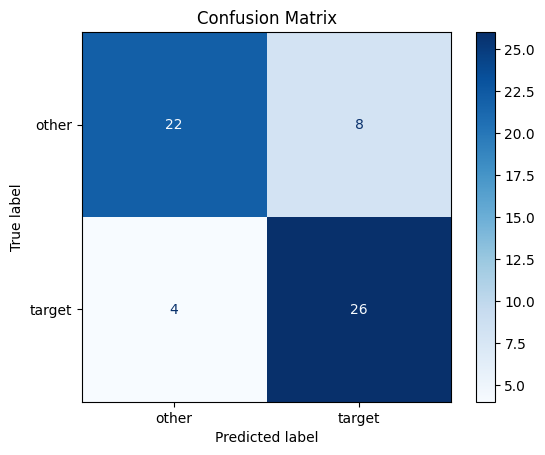

              precision    recall  f1-score   support

       other       0.85      0.73      0.79        30
      target       0.76      0.87      0.81        30

    accuracy                           0.80        60
   macro avg       0.81      0.80      0.80        60
weighted avg       0.81      0.80      0.80        60



In [237]:
cm = confusion_matrix(yt, yp)
dp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tr_ds.classes)

dp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(yt, yp, target_names=tr_ds.classes))

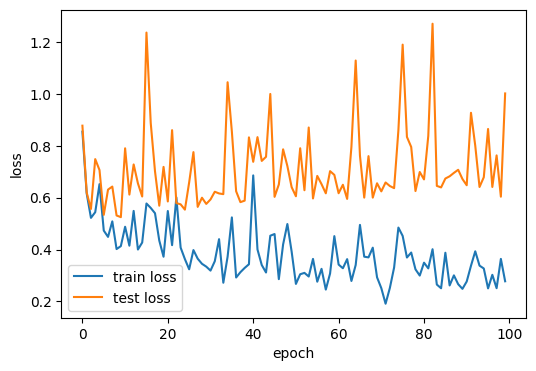

In [238]:
plt.figure(figsize=(6, 4))
plt.plot(h["tr_l"], label="train loss")
plt.plot(h["ts_l"], label="test loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.savefig('epoch vs loss.png')
plt.show()

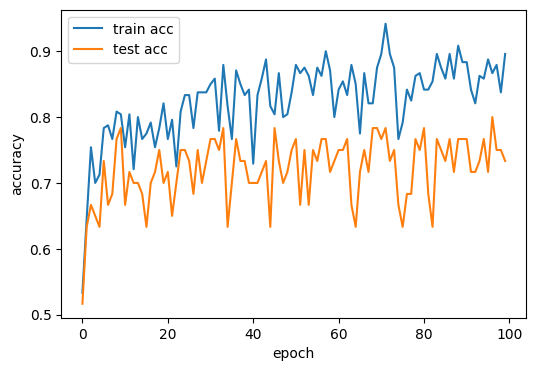

In [239]:
plt.figure(figsize=(6, 4))
plt.plot(h["tr_a"], label="train acc")
plt.plot(h["ts_a"], label="test acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.savefig('epoch vs accuracy.png')
plt.show()

## Model Evaluation

The results show that the model is starting to recognize key facial features that help it identify CR7 (Cristiano Ronaldo) among other faces, but its overall performance is just average.

According to the confusion matrix, the model successfully identified 26 out of 30 images of CR7, which is a good sign. However, it also misidentified 8 images of other people as CR7, meaning it's more accurate at recognizing him than at distinguishing him from non-CR7 faces. Additionally, it missed 4 images of CR7 altogether, suggesting it sometimes overlooks the target.

The classification report supports these findings. It highlights that the model is good at finding most images of CR7, achieving a recall score of 0.87. On the other hand, when it predicts an image as CR7, it gets it wrong about 24% of the time, resulting in a precision score of 0.76. For identifying images of other faces, the model is less effective, with a recall score of 0.73, indicating it struggles more with faces that look similar to CR7. In total, the model's accuracy stands at 80%, which shows it performs reasonably well but still has room for improvement.

#Loss graph and Accuracy graph
In the loss graph, the training loss generally goes down, meaning the model gets better at fitting the training data over time. However, the test loss remains higher and shows a lot of fluctuation, with several spikes. This instability indicates that the model does not generalize well to new images. Essentially, it performs better on the training set than on the test set.

In the accuracy graph, the training accuracy gradually increases into the high 0.8 range. In contrast, the test accuracy stays lower, mostly in the low-to-mid 0.7s, with some ups and downs. This difference between training and test accuracy shows signs of overfitting. The model has learned patterns from the training images, but some of these patterns do not work well with new images.

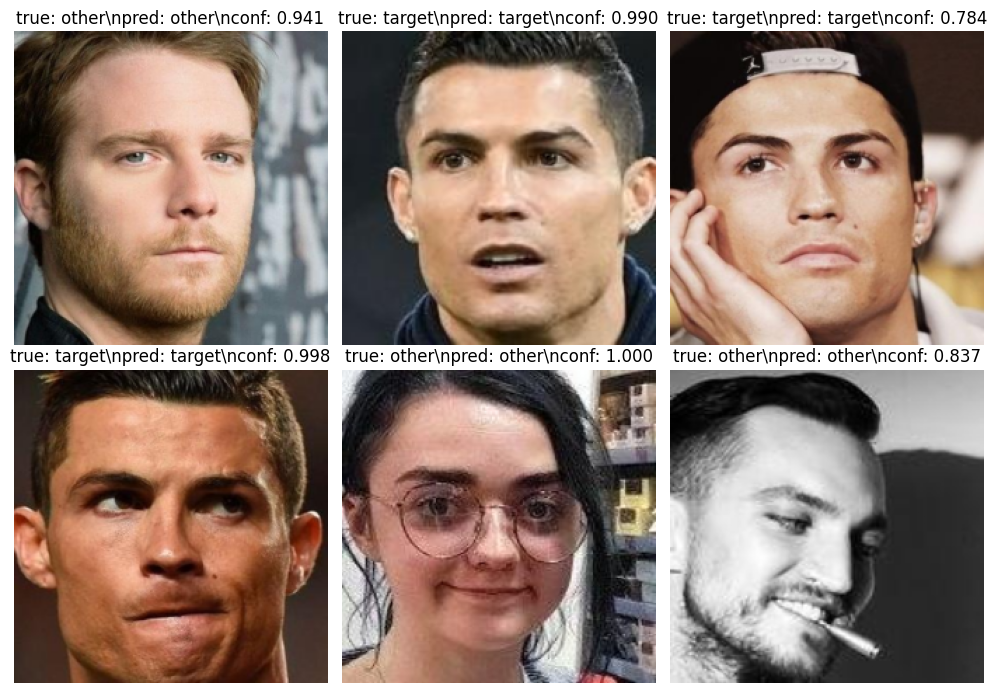

In [240]:
ix = random.sample(range(len(ts_ds)), 6)

fig, ax = plt.subplots(2, 3, figsize=(10, 7))

for a1, i in zip(ax.ravel(), ix):
    x, y = ts_ds[i]

    with torch.no_grad():
        z = m(x.unsqueeze(0).to(d))
        pr = torch.softmax(z, dim=1).cpu().numpy()[0]
        pd = int(np.argmax(pr))
        cf = float(np.max(pr))

    a1.imshow(x.permute(1, 2, 0))
    a1.set_title(f"true: {tr_ds.classes[y]}\\npred: {tr_ds.classes[pd]}\\nconf: {cf:.3f}")
    a1.axis("off")

plt.tight_layout()
plt.show()

In [241]:
from google.colab import files
up = files.upload()

Saving Cristiano_Ronaldo,_2023.jpg to Cristiano_Ronaldo,_2023 (2).jpg


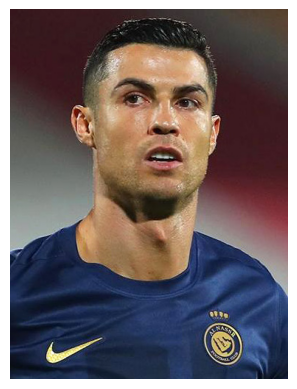

Predicted class: target
Confidence: 0.9713746905326843
All probabilities: [0.02862533 0.9713747 ]


In [242]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
import numpy as np

fn = list(up.keys())[0]
img = Image.open(fn).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

x = tf(img).unsqueeze(0).to(d)

m.eval()
with torch.no_grad():
    z = m(x)
    pr = torch.softmax(z, dim=1)[0].cpu().numpy()
    pd = int(np.argmax(pr))
    cf = float(np.max(pr))

print("Predicted class:", tr_ds.classes[pd])
print("Confidence:", cf)
print("All probabilities:", pr)

## Results Discussion

To evaluate the model more carefully, I tested it with individual uploaded images and new examples. This helped me see if the classifier really recognized CR7's facial features or just memorized the training data.

The best predictions happened when the uploaded image showed a clear, front-facing face with good lighting. The model struggled more with blurry images, side profiles, unusual lighting, many faces, or pictures without faces.

Since this is a binary face-classification project, the model's job is simple: it must decide whether an image is of Cristiano Ronaldo or not. So, if someone uploads a non-face image or if the image quality is poor, the model usually predicts the safer option, which is "not CR7."

These results show that the model can perform well, but they also highlight the need for high-quality data.

## Final Conclusion

In this project, I created a facial image classifier to distinguish between Cristiano Ronaldo (CR7) and not CR7 using transfer learning with ResNet18. The notebook outlined the entire machine learning process, including dataset preparation, preprocessing, model customization, training, evaluation, and prediction testing.

Transfer learning was effective because the pre-trained model already recognized useful visual features, which I adapted for this task. By retraining just the final classification layer, I reduced training time while still achieving a functional classifier.

Future improvements could include increasing the size of the CR7 dataset, fine-tuning deeper layers of ResNet18, adding more diverse images of the negative class, and deploying the final model through a Streamlit interface.

## References

1. PyTorch Documentation. *ResNet18 Model Documentation*.  
2. PyTorch Tutorials. *Transfer Learning for Computer Vision Tutorial*.  
3. Streamlit Documentation.  
4. Torchvision Documentation. *ImageFolder Dataset*.  
5. Hugging Face Datasets. *jtatman/one_twenty_five_faces*. https://huggingface.co/datasets/jtatman/one_twenty_five_faces

In [243]:
torch.save(m.state_dict(), "cr_resnet18.pth")
print("saved")

saved


In [314]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image

st.set_page_config(
    page_title="CR7 Classifier",
    layout="centered"
)

st.markdown("""
<style>
.main {
    background: linear-gradient(135deg, #f8fbff 0%, #eef4ff 45%, #fdf2f8 100%);
}
.block-container {
    max-width: 850px;
    padding-top: 2rem;
    padding-bottom: 2rem;
}
.title-wrap {
    text-align: center;
    padding: 1rem 0 0.5rem 0;
}
.main-title {
    font-size: 2.6rem;
    font-weight: 800;
    color: #1f2937;
    margin-bottom: 0.25rem;
}
.sub-title {
    font-size: 1.05rem;
    color: #4b5563;
    margin-bottom: 1.2rem;
}
.card {
    background: rgba(255,255,255,0.9);
    border-radius: 22px;
    padding: 1.4rem;
    box-shadow: 0 10px 30px rgba(31,41,55,0.10);
    margin-bottom: 1.2rem;
}
.good {
    padding: 0.45rem 0.9rem;
    border-radius: 999px;
    background: #dcfce7;
    color: #166534;
    font-weight: 700;
    display: inline-block;
}
.bad {
    padding: 0.45rem 0.9rem;
    border-radius: 999px;
    background: #fee2e2;
    color: #991b1b;
    font-weight: 700;
    display: inline-block;
}
.small {
    color: #6b7280;
    font-size: 0.95rem;
}
</style>
""", unsafe_allow_html=True)

d = torch.device("cpu")

m = models.resnet18(weights=None)
f = m.fc.in_features
m.fc = nn.Linear(f, 2)
m.load_state_dict(torch.load("cr_resnet18.pth", map_location=d))
m.eval()

cr7_idx = 1

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

st.markdown("""
<div class="title-wrap">
    <div class="main-title">CR7 or Not?</div>
    <div class="sub-title">
        Upload one face image and the model will decide whether it is Cristiano Ronaldo.
    </div>
</div>
""", unsafe_allow_html=True)

st.markdown('<div class="card">', unsafe_allow_html=True)
up = st.file_uploader("Upload image", type=["jpg", "jpeg", "png"])
st.markdown('</div>', unsafe_allow_html=True)

if up is not None:
    img = Image.open(up).convert("RGB")
    x = tf(img).unsqueeze(0).to(d)

    with torch.no_grad():
        z = m(x)
        pr = torch.softmax(z, dim=1)[0].cpu()

    p_cr7 = float(pr[cr7_idx].item())
    p_not = 1.0 - p_cr7

    th = 0.5

    c1, c2 = st.columns([1.1, 0.9])

    with c1:
        st.markdown('<div class="card">', unsafe_allow_html=True)
        st.image(img, caption="Uploaded image", use_container_width=True)
        st.markdown('</div>', unsafe_allow_html=True)

    with c2:
        st.markdown('<div class="card">', unsafe_allow_html=True)
        st.subheader("Result")

        if p_cr7 >= th:
            st.markdown('<span class="good">CR7</span>', unsafe_allow_html=True)
            st.success("The model predicts this image is Cristiano Ronaldo.")
        else:
            st.markdown('<span class="bad">Not CR7</span>', unsafe_allow_html=True)
            st.error("The model predicts this image is not Cristiano Ronaldo.")

        st.write(f"**CR7 probability:** `{p_cr7:.4f}`")
        st.progress(min(max(p_cr7, 0.0), 1.0))

        st.write(f"**Not CR7 probability:** `{p_not:.4f}`")
        st.progress(min(max(p_not, 0.0), 1.0))

        st.markdown('</div>', unsafe_allow_html=True)
else:
    st.markdown("""
    <div class="card">
        <h3 style="margin-top:0;">Binary Classification Task (2 classes)</h3>
        <div class="small">
            This app does only one thing:
            <ul>
                <li><b>CR7</b></li>
                <li><b>Not CR7</b></li>
            </ul>
        </div>
    </div>
    """, unsafe_allow_html=True)

Writing app.py


In [302]:
!pip install -q streamlit pyngrok

In [303]:
from pyngrok import ngrok

In [304]:
!streamlit run app.py &>/content/log.txt &

In [312]:
ngrok.set_auth_token("3AJUFv4Vrg4VT4cVTVX4ZCVsqTQ_2jFKKsjCBL9LGqwy8odX")

In [315]:
u = ngrok.connect(8501)
print(u)

NgrokTunnel: "https://nonmicroscopical-polluted-tonette.ngrok-free.dev" -> "http://localhost:8501"
